18000
3600
X_train shape: (18000, 32, 32)
X_test shape : (3600, 32, 32)
y_train 예시: ['0L', '0L', '2L', '0L', '5L']
y_test 예시 : ['5L', '5L', '3R', '5L', '5L']


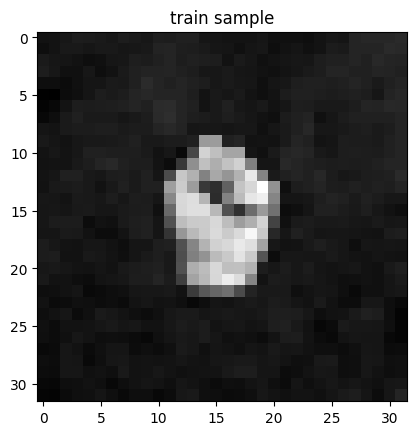

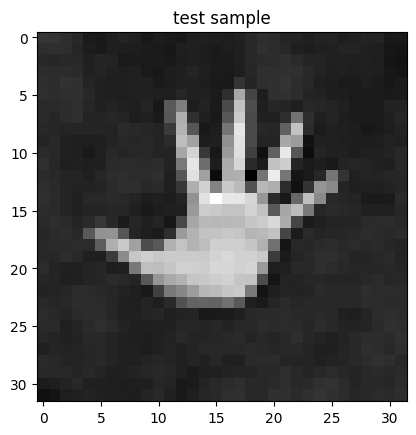

In [55]:
import warnings
warnings.filterwarnings('ignore')

import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow import keras

train_images= glob.glob("../Data/fingers/train/*.png")
test_images= glob.glob("../Data/fingers/test/*.png")

train_images[:5]
test_images[:5]

print(len(train_images))
print(len(test_images))

X_train=[]
X_test=[]
y_train=[]
y_test=[]#파이썬은 리스트

#train data
for image in sorted(train_images):
    # print(image)
    img = Image.open(image)#img=그림/ image=파일이름
    imgResize=img.resize((32,32), Image.Resampling.LANCZOS)#계단 현상/깨짐방지
    X_train.append(imgResize)
    y_train.append(image[-6:-4])

#test data
for image in sorted(test_images):
    # print(image)
    img = Image.open(image)#img=그림/ image=파일이름
    imgResize=img.resize((32,32), Image.Resampling.LANCZOS)#계단 현상/깨짐방지
    X_test.append(imgResize)
    y_test.append(image[-6:-4])


# numpy 배열로 변환
X_train = np.array(X_train)
X_test = np.array(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train 예시:", y_train[:5])
print("y_test 예시 :", y_test[:5])

# 이미지 확인
plt.imshow(X_train[0], cmap='gray')
plt.title("train sample")
plt.show()

plt.imshow(X_test[0], cmap='gray')
plt.title("test sample")
plt.show()

In [56]:
# import numpy as np
# tempData = np.zeros((len(X_train), 32, 32), dtype=np.int32)


# i=0
# for image in X_train:
#     img=np.array(image, dtype=np.int32)#2차원 데이터
#     tempData[i,:,:] = img
#     i+=1

# X_train=tempData.copy()

# tempData = np.zeros((len(X_test), 32, 32), dtype=np.int32)
# i=0
# for image in X_test:
#     img=np.array(image, dtype=np.int32)#2차원 데이터
#     tempData[i,:,:] = img
#     i+=1

# X_test= tempData.copy()

# tempData.shape
# print(X_train.shape, X_test.shape)

In [57]:
label_to_int={
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11
}
temp=[]
for label in y_train:
    temp.append(label_to_int[label])
y_train= temp.copy()

temp=[]#list
for label in y_test:
    temp.append(label_to_int[label])
y_test= temp.copy()

#list=>numpy
y_train=np.array(y_train)
y_test=np.array(y_test)

In [58]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNN 입력 형태: (개수, 32, 32, 1)
X_train = X_train.reshape(-1, 32, 32, 1)
X_test = X_test.reshape(-1, 32, 32, 1)

print("CNN용 X_train shape:", X_train.shape)
print("CNN용 X_test shape :", X_test.shape)

CNN용 X_train shape: (18000, 32, 32, 1)
CNN용 X_test shape : (3600, 32, 32, 1)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,728 (1.64 MB)

 Trainable params: 429,728 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8623 - loss: 0.4345 - val_accuracy: 0.9972 - val_loss: 0.0117
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9926 - loss: 0.0287 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9960 - loss: 0.0141 - val_accuracy: 1.0000 - val_loss: 5.5792e-04
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9964 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 9.1695e-04
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9974 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 4.8267e-04
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9982 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 1.6848e-05
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9984 - loss: 0.0049 - val_accuracy: 1.0000 - val_loss: 1.0842e-04
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9981 - los

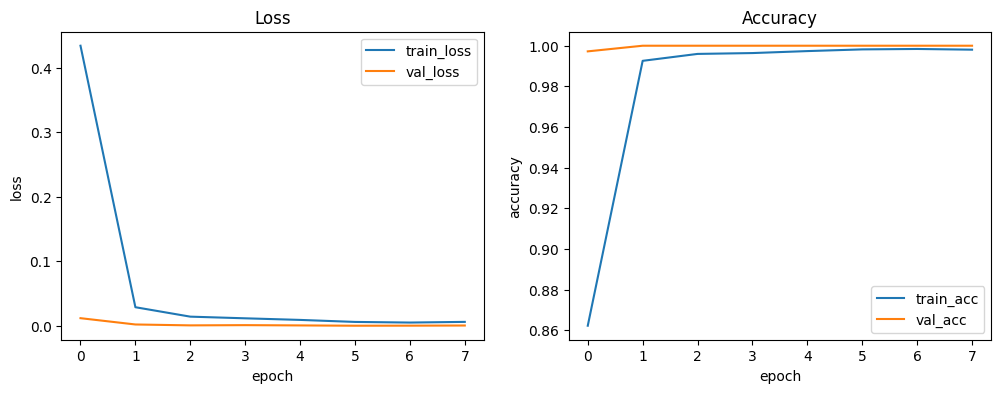

563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 1.4536e-05
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.6848e-05
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.0651e-05
train loss: 1.4535850823449437e-05
train accuracy: 1.0
val loss: 1.6847778169903904e-05
val accuracy: 1.0
test loss: 2.06511867872905e-05
test accuracy: 1.0


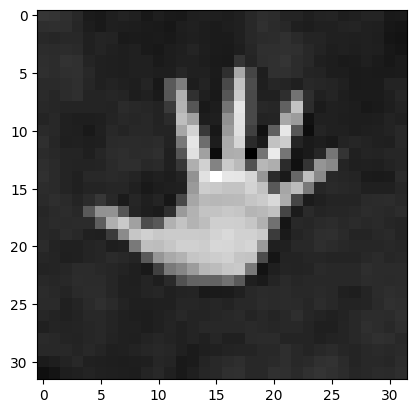

In [59]:
# train -> train, valid 분리
train_input, val_input, train_target, val_target = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = keras.Sequential()

model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same',
    input_shape=(32, 32, 1)
))
model.add(keras.layers.MaxPool2D(2))

model.add(keras.layers.Conv2D(
    64,
    kernel_size=3,
    activation='relu',
    padding='same'
))
model.add(keras.layers.MaxPool2D(2))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(12, activation='softmax'))

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "../Data/best_model.keras",
    save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_input,
    train_target,
    epochs=20,
    validation_data=(val_input, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

train_loss, train_acc = model.evaluate(X_train, y_train)
val_loss, val_acc = model.evaluate(val_input, val_target)
test_loss, test_acc = model.evaluate(X_test, y_test)

print("train loss:", train_loss)
print("train accuracy:", train_acc)
print("val loss:", val_loss)
print("val accuracy:", val_acc)
print("test loss:", test_loss)
print("test accuracy:", test_acc)

plt.imshow(X_test[0].reshape(32, 32), cmap='gray')
plt.show()


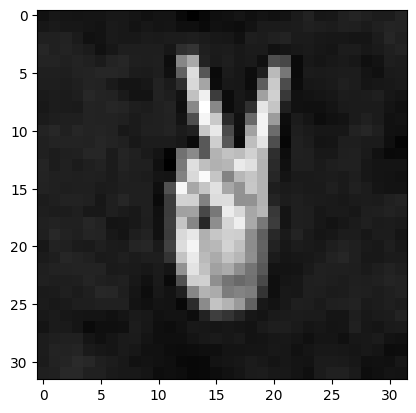

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
예측 확률: [[1.47716247e-19 6.92349573e-08 9.99999762e-01 1.10067582e-07
  1.25883376e-16 2.84738108e-19 4.98599626e-20 3.28056511e-13
  2.05352491e-09 3.17455453e-13 1.20932574e-23 2.54141224e-15]]
예측 클래스: 2R


In [ ]:
img = Image.open("../Data/KakaoTalk_Photo_2026-04-16-14-25-37.png").convert('L')
img = img.resize((32, 32), Image.Resampling.LANCZOS)
img_arr = np.array(img, dtype=np.float32) / 255.0

plt.imshow(img_arr, cmap='gray')
plt.show()

img_input = img_arr.reshape(1, 32, 32, 1)
pred = model.predict(img_input)

classes = ['0R', '1R', '2R', '3R', '4R', '5R', '0L', '1L', '2L', '3L', '4L', '5L']
print("예측 확률:", pred)
print("예측 클래스:", classes[np.argmax(pred)])
#센터화가 중요